# Pixel Operations

This notebook contains code tests and visualizations for pixel operations.

Operacje na pikselach: 
- Konwersja do odcieni szarości,  
- Korekta jasności,  
- Korekta kontrastu,  
- Negatyw,  
- Binaryzacja.

In [4]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

import sys
sys.path.append('../src')
from basic_operations import to_grayscale, adjust_brightness, adjust_contrast, negative, equalize_histogram
from thresholding import binarize, otsu_threshold, binarize_otsu
from analysis import compute_histogram, horizontal_projection, vertical_projection

In [2]:
def show_image(img_array, title="Obraz", cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(img_array, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

## Tests

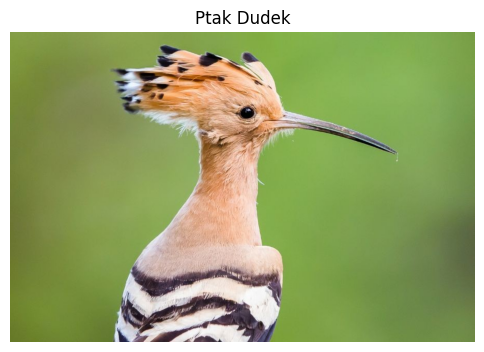

In [6]:
# Wczytanie obrazu
image_path = "../data/ptak_dudek.jpg"
img_pil = Image.open(image_path)
img_rgb = np.array(img_pil)

show_image(img_rgb, "Ptak Dudek")

Histogram RGB:


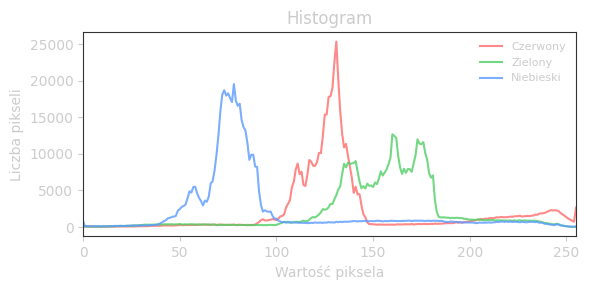

In [44]:
print("Histogram RGB:")
fig_hist_rgb = compute_histogram(img_rgb)
display(fig_hist_rgb)

Projekcja pozioma (Obraz binarny):


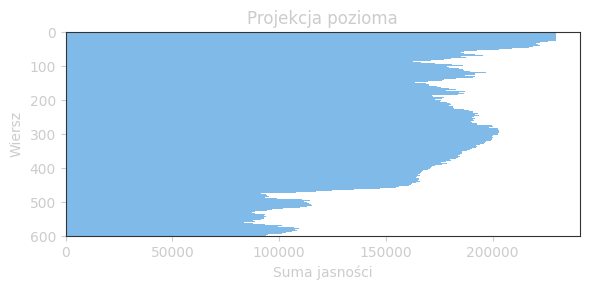

Projekcja pionowa (Obraz binarny):


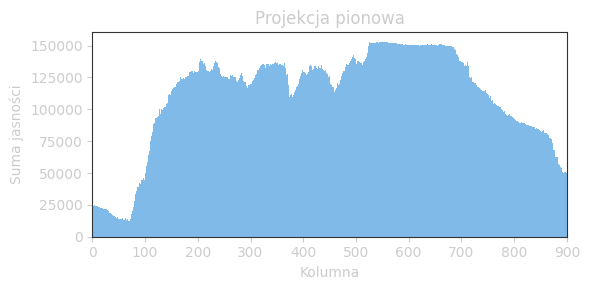

In [45]:
img_bin = binarize(img_rgb, threshold=128)

print("Projekcja pozioma (Obraz binarny):")
fig_h_proj = horizontal_projection(img_bin)
display(fig_h_proj)

print("Projekcja pionowa (Obraz binarny):")
fig_v_proj = vertical_projection(img_bin)
display(fig_v_proj)

## Operations

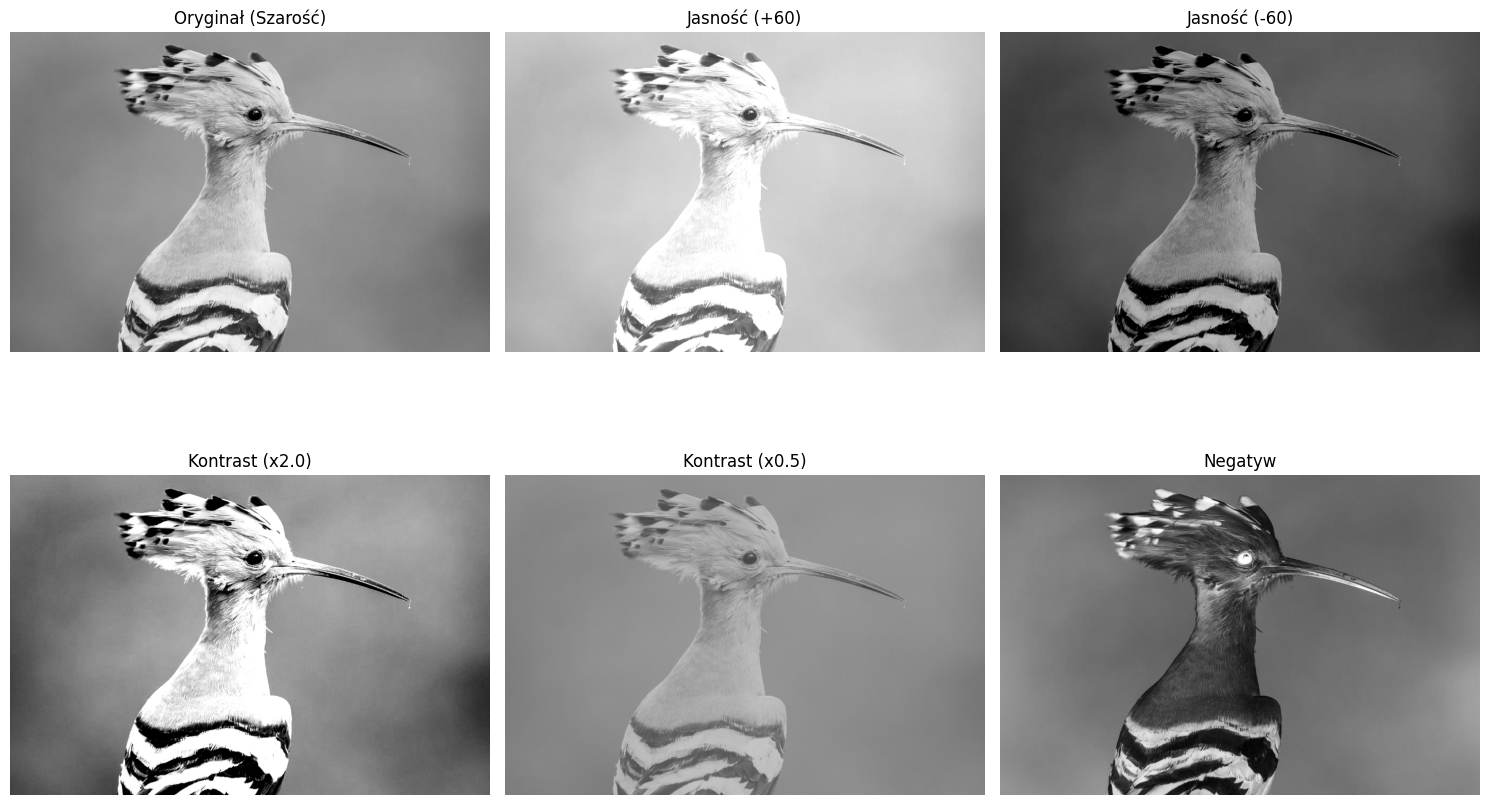

In [9]:
# Operacje
img_gray = to_grayscale(img_rgb)
img_bright = adjust_brightness(img_gray, value=60)      # Rozjaśnienie
img_dark = adjust_brightness(img_gray, value=-60)       # Przyciemnienie
img_contrast_high = adjust_contrast(img_gray, factor=2.0) # Zwiększenie kontrastu
img_contrast_low = adjust_contrast(img_gray, factor=0.5)  # Zmniejszenie kontrastu
img_neg = negative(img_gray)

# Wyniki
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax = axes.ravel()

images = {
    "Oryginał (Szarość)": img_gray,
    "Jasność (+60)": img_bright,
    "Jasność (-60)": img_dark,
    "Kontrast (x2.0)": img_contrast_high,
    "Kontrast (x0.5)": img_contrast_low,
    "Negatyw": img_neg
}

for i, (title, img) in enumerate(images.items()):
    ax[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

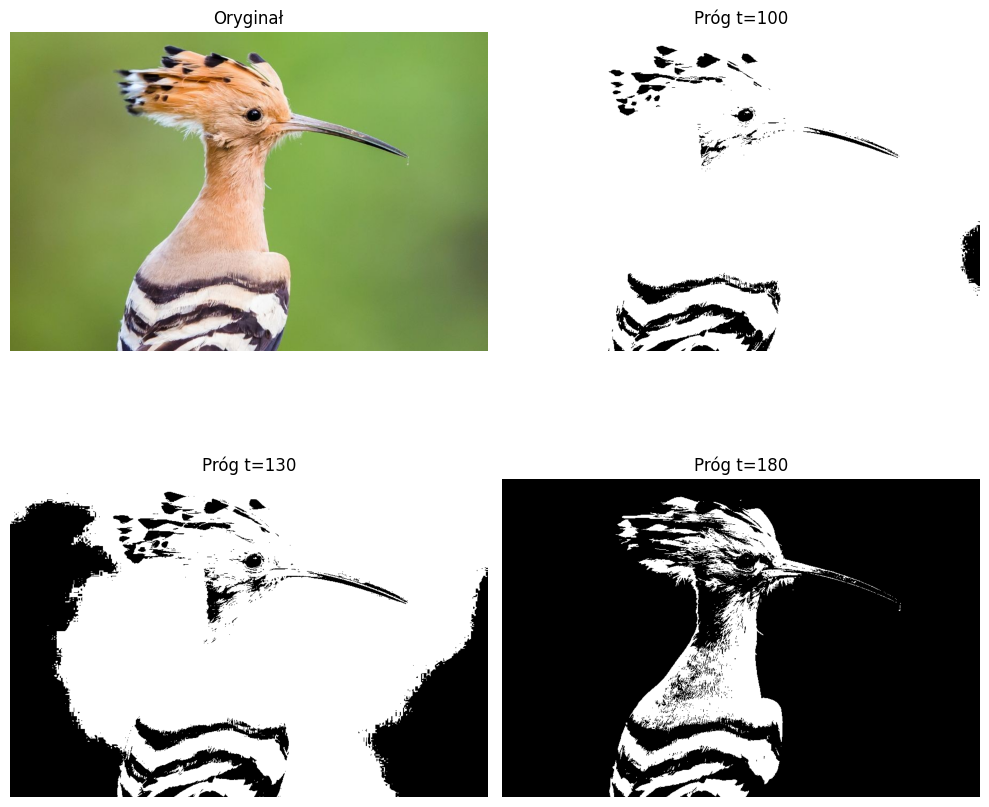

In [41]:
# Binaryzacja z różnymi progami
img_bin_100 = binarize(img_rgb, threshold=100)
img_bin_130 = binarize(img_rgb, threshold=130)
img_bin_180 = binarize(img_rgb, threshold=180)

# Wyniki
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
ax = axes.ravel()

images = {
    "Oryginał": img_rgb,
    "Próg t=100": img_bin_100,
    "Próg t=130": img_bin_130,
    "Próg t=180": img_bin_180
}

for i, (title, img) in enumerate(images.items()):
    ax[i].imshow(img, cmap='gray' if len(img.shape) == 2 else None, vmin=0, vmax=255)
    ax[i].set_title(title)
    ax[i].axis('off')

plt.tight_layout()
plt.show()

Automatycznie wyznaczony próg metodą Otsu: 169


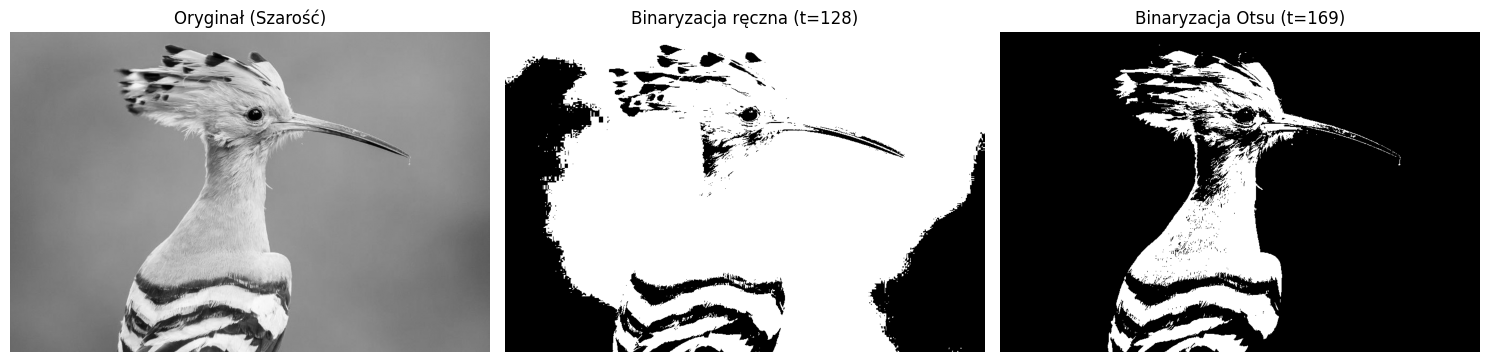

In [8]:
img_gray = to_grayscale(img_rgb)

# Wyznaczenie progu Otsu i binaryzacja
optimal_t = otsu_threshold(img_gray)
img_otsu = binarize_otsu(img_gray)

# Ręczna binaryzacja dla porównania
img_manual = binarize(img_gray, threshold=128)

print(f"Automatycznie wyznaczony próg metodą Otsu: {optimal_t}")

# Wyświetlenie wyników
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Oryginał (Szarość)")
axes[0].axis('off')

axes[1].imshow(img_manual, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Binaryzacja ręczna (t=128)")
axes[1].axis('off')

axes[2].imshow(img_otsu, cmap='gray', vmin=0, vmax=255)
axes[2].set_title(f"Binaryzacja Otsu (t={optimal_t})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

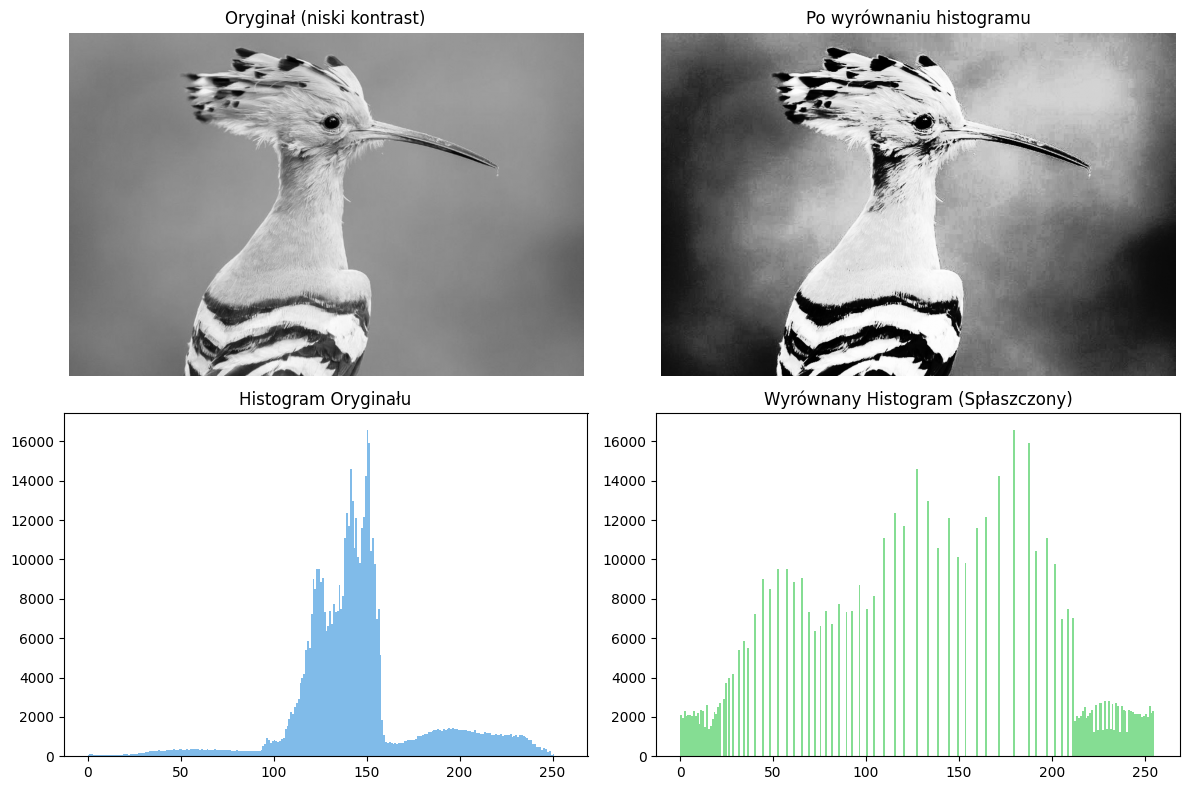

In [10]:
# Wyrównywanie histogramu
img_eq = equalize_histogram(img_gray)

# Wyniki
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Oryginał
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Oryginał (niski kontrast)")
axes[0, 0].axis('off')
# Jego histogram
axes[1, 0].hist(img_gray.flatten(), bins=256, range=[0,256], color='#4A9EE0', alpha=0.7)
axes[1, 0].set_title("Histogram Oryginału")

# Obraz po wyrównaniu
axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Po wyrównaniu histogramu")
axes[0, 1].axis('off')
# Jego histogram
axes[1, 1].hist(img_eq.flatten(), bins=256, range=[0,256], color='#51CF66', alpha=0.7)
axes[1, 1].set_title("Wyrównany Histogram (Spłaszczony)")

plt.tight_layout()
plt.show()